=== KẾT QUẢ PHÂN CỤM SINH VIÊN ===
   Toan  Ly  Cluster
0     9   8        2
1     8   8        2
2     8   7        2
3     7   7        0
4     6   6        0
5     5   5        0
6     4   4        1
7     3   3        1
8     2   2        1
9     1   1        1


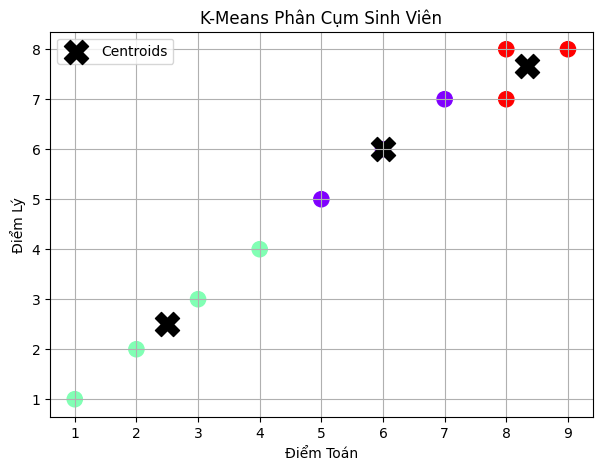


=== KẾT QUẢ K-NN ===
Độ chính xác: 1.0
Dự đoán loại hoa: 0


In [1]:
# =========================================================
# BÀI 4
# MÔ TẢ ỨNG DỤNG VÀ DEMO K-MEANS + K-NN
# =========================================================

"""
ỨNG DỤNG THỰC TẾ

1. K-Means
- Phân cụm khách hàng.
- Phân nhóm sinh viên theo điểm.
- Phân tích dữ liệu thị trường.
- Gom nhóm ảnh.

2. K-NN
- Nhận dạng chữ viết tay.
- Phân loại hoa Iris.
- Dự đoán bệnh.
- Nhận diện đối tượng.

Bài demo:
- K-Means dùng để phân cụm sinh viên theo điểm.
- K-NN dùng để phân loại hoa Iris.
"""

# =========================================================
# IMPORT THƯ VIỆN
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# =========================================================
# PHẦN 1: DEMO K-MEANS
# PHÂN CỤM SINH VIÊN
# =========================================================

# Dữ liệu mẫu
students = pd.DataFrame({
    'Toan': [9,8,8,7,6,5,4,3,2,1],
    'Ly':   [8,8,7,7,6,5,4,3,2,1]
})

X = students.values

# Khởi tạo mô hình
kmeans = KMeans(n_clusters=3, random_state=42)

# Huấn luyện
students['Cluster'] = kmeans.fit_predict(X)

print("=== KẾT QUẢ PHÂN CỤM SINH VIÊN ===")
print(students)

# Vẽ biểu đồ
plt.figure(figsize=(7,5))

plt.scatter(
    students['Toan'],
    students['Ly'],
    c=students['Cluster'],
    cmap='rainbow',
    s=120
)

# Tâm cụm
centers = kmeans.cluster_centers_

plt.scatter(
    centers[:,0],
    centers[:,1],
    color='black',
    marker='X',
    s=300,
    label='Centroids'
)

plt.xlabel("Điểm Toán")
plt.ylabel("Điểm Lý")
plt.title("K-Means Phân Cụm Sinh Viên")
plt.legend()
plt.grid(True)

plt.show()

# =========================================================
# PHẦN 2: DEMO K-NN
# PHÂN LOẠI HOA IRIS
# =========================================================

iris = load_iris()

X = iris.data
y = iris.target

# Chia dữ liệu train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Tạo mô hình
knn = KNeighborsClassifier(n_neighbors=5)

# Huấn luyện
knn.fit(X_train, y_train)

# Dự đoán
y_pred = knn.predict(X_test)

# Độ chính xác
accuracy = accuracy_score(y_test, y_pred)

print("\n=== KẾT QUẢ K-NN ===")
print("Độ chính xác:", accuracy)

# Dự đoán mẫu mới
sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = knn.predict(sample)

print("Dự đoán loại hoa:", prediction[0])

========== K-MEANS ==========


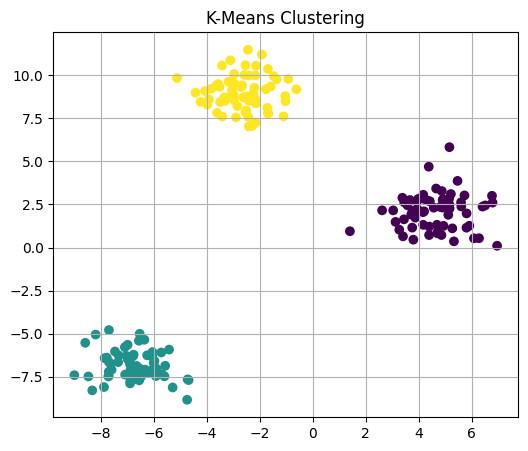


========== K-NN ==========
Độ chính xác KNN: 1.0

========== LINEAR REGRESSION ==========
Mean Squared Error: 78.054250421239


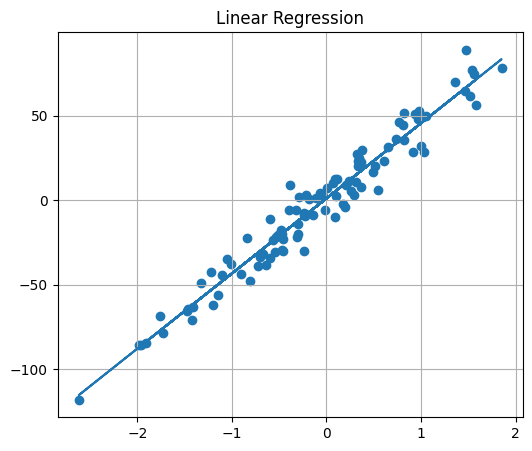


========== DECISION TREE ==========
Độ chính xác Decision Tree: 1.0


In [2]:
# =========================================================
# BÀI 5
# DEMO CÁC THUẬT TOÁN ĐÃ HỌC TRÊN LỚP
# =========================================================

"""
CÁC THUẬT TOÁN DEMO

1. K-Means      -> Phân cụm dữ liệu
2. K-NN         -> Phân loại dữ liệu
3. Linear Regression -> Dự đoán
4. Decision Tree -> Cây quyết định

Ứng dụng:
- AI
- Machine Learning
- Dự đoán dữ liệu
- Phân tích dữ liệu
"""

# =========================================================
# IMPORT THƯ VIỆN
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import (
    make_blobs,
    load_iris,
    make_regression
)

from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

# =========================================================
# PHẦN 1: K-MEANS
# =========================================================

print("========== K-MEANS ==========")

X, y = make_blobs(
    n_samples=200,
    centers=3,
    random_state=42
)

kmeans = KMeans(n_clusters=3)

labels = kmeans.fit_predict(X)

plt.figure(figsize=(6,5))

plt.scatter(
    X[:,0],
    X[:,1],
    c=labels,
    cmap='viridis'
)

plt.title("K-Means Clustering")
plt.grid(True)

plt.show()

# =========================================================
# PHẦN 2: K-NN
# =========================================================

print("\n========== K-NN ==========")

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Độ chính xác KNN:",
      accuracy_score(y_test, y_pred))

# =========================================================
# PHẦN 3: LINEAR REGRESSION
# =========================================================

print("\n========== LINEAR REGRESSION ==========")

X, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=10,
    random_state=42
)

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)

print("Mean Squared Error:", mse)

plt.figure(figsize=(6,5))

plt.scatter(X, y)

plt.plot(X, y_pred)

plt.title("Linear Regression")
plt.grid(True)

plt.show()

# =========================================================
# PHẦN 4: DECISION TREE
# =========================================================

print("\n========== DECISION TREE ==========")

tree = DecisionTreeClassifier()

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Độ chính xác Decision Tree:",
      accuracy_score(y_test, y_pred_tree))